# Notebook 2: Pelatihan Agen Deep Q-Network (DQN)

**Proyek** : Dynamic Pricing untuk Asuransi Kesehatan

**Tujuan Notebook Ini** :
1. Mendefinisikan ulang environment (self-contained, tidak memerlukan impor dari notebook lain).
2. Melatih agen DQN menggunakan Stable-Baselines3.
3. Memplot kurva pembelajaran (reward per episode).
4. Menyimpan model terlatih untuk digunakan pada notebook evaluasi.

---

## Arsitektur DQN yang Digunakan

```
Input  [6]  -->  Dense [64, ReLU]  -->  Dense [64, ReLU]  -->  Output [5]
```

Setiap neuron output merepresentasikan Q-value untuk satu aksi diskret.

---

## Rumus Pembaruan Q-Network

### Bellman Equation (Q-Learning Tabular)

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

### Loss Function DQN (Mean Squared Bellman Error)

$$\mathcal{L}(\theta) = \mathbb{E}_{(s,a,r,s') \sim \mathcal{D}} \left[ \left( r + \gamma \max_{a'} Q_{\theta^-}(s', a') - Q_{\theta}(s, a) \right)^2 \right]$$

| Simbol | Definisi |
|--------|----------|
| $\theta$ | Bobot Q-network utama (online network) |
| $\theta^-$ | Bobot target network (diperbarui secara periodik) |
| $\mathcal{D}$ | Replay buffer (kumpulan transisi $(s, a, r, s', \text{done})$) |
| $\gamma$ | Discount factor = 0.95 |
| $\alpha$ | Learning rate = 0.001 |

## 1. Import Library

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import StandardScaler, LabelEncoder
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

print("Library berhasil diimpor.")

Library berhasil diimpor.


## 2. Konfigurasi

In [2]:
# ============================================================
# PATH
# ============================================================
DATASET_PATH  = "../medical_insurance.csv"
ARTIFACT_DIR  = "./artifacts"
MODEL_DIR     = "./models"
LOG_DIR       = "./logs"

for d in [ARTIFACT_DIR, MODEL_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

# ============================================================
# HYPERPARAMETER DQN
# ============================================================
TOTAL_TIMESTEPS        = 200_000   # Total langkah pelatihan
LEARNING_RATE          = 1e-3      # Laju belajar (alpha)
BATCH_SIZE             = 64        # Ukuran mini-batch
BUFFER_SIZE            = 50_000    # Kapasitas replay buffer
EXPLORATION_FRACTION   = 0.3       # Fraksi timesteps untuk epsilon decay
EXPLORATION_FINAL_EPS  = 0.05      # Epsilon minimum
GAMMA                  = 0.95      # Discount factor
TRAIN_FREQ             = 4         # Update jaringan setiap N langkah
TARGET_UPDATE_INTERVAL = 500       # Interval pembaruan target network
SEED                   = 42

print("Konfigurasi:")
print(f"  Total timesteps        : {TOTAL_TIMESTEPS:,}")
print(f"  Learning rate          : {LEARNING_RATE}")
print(f"  Batch size             : {BATCH_SIZE}")
print(f"  Buffer size            : {BUFFER_SIZE:,}")
print(f"  Gamma (discount factor): {GAMMA}")
print(f"  Epsilon awal -> akhir  : 1.0 -> {EXPLORATION_FINAL_EPS}")
print(f"  Target network update  : setiap {TARGET_UPDATE_INTERVAL} langkah")

Konfigurasi:
  Total timesteps        : 200,000
  Learning rate          : 0.001
  Batch size             : 64
  Buffer size            : 50,000
  Gamma (discount factor): 0.95
  Epsilon awal -> akhir  : 1.0 -> 0.05
  Target network update  : setiap 500 langkah


## 3. Preprocessing Data (Ulang, Self-Contained)

In [3]:
def load_and_preprocess(filepath: str):
    """Memuat dan memproses dataset asuransi."""
    df = pd.read_csv(filepath)

    categorical_cols = ["gender", "discount_eligibility", "region"]
    encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le

    feature_cols = ["age", "gender", "bmi", "children", "discount_eligibility", "region"]
    numeric_cols = ["age", "bmi", "children"]

    scaler = StandardScaler()
    df_features = df[feature_cols].copy()
    df_features[numeric_cols] = scaler.fit_transform(df[numeric_cols])

    states   = df_features.values.astype(np.float32)
    expenses = df["expenses"].values.astype(np.float32)
    premiums = df["premium"].values.astype(np.float32)

    return states, expenses, premiums, scaler, encoders


states, expenses, premiums, scaler, encoders = load_and_preprocess(DATASET_PATH)
print(f"Data berhasil dimuat: {states.shape[0]} sampel, {states.shape[1]} fitur.")

Data berhasil dimuat: 1338 sampel, 6 fitur.


## 4. Definisi Environment (Self-Contained)

In [4]:
class InsurancePricingEnv(gym.Env):
    """Custom Gymnasium Environment untuk Penetapan Harga Dinamis Asuransi."""

    metadata = {"render_modes": ["human"]}
    ACTION_MULTIPLIERS = np.array([0.8, 0.9, 1.0, 1.1, 1.2], dtype=np.float32)

    def __init__(self, states, expenses, premiums,
                 penalty_threshold=1.5, penalty_coef=2.0):
        super().__init__()
        self.states            = states
        self.expenses          = expenses
        self.premiums          = premiums
        self.n_samples         = len(states)
        self.penalty_threshold = penalty_threshold
        self.penalty_coef      = penalty_coef
        self.action_space      = spaces.Discrete(len(self.ACTION_MULTIPLIERS))
        obs_dim = states.shape[1]
        self.observation_space = spaces.Box(-np.inf, np.inf, (obs_dim,), np.float32)
        self._current_idx  = 0
        self._last_info    = {}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._current_idx = 0
        return self.states[0], {}

    def step(self, action: int):
        idx             = self._current_idx
        base_premium    = float(self.premiums[idx])
        actual_expenses = float(self.expenses[idx])
        multiplier      = float(self.ACTION_MULTIPLIERS[action])
        proposed        = base_premium * multiplier
        profit          = proposed - actual_expenses
        excess          = proposed - self.penalty_threshold * actual_expenses
        penalty         = self.penalty_coef * max(0.0, excess)
        reward          = float(np.clip((profit - penalty) / 1000.0, -10.0, 10.0))
        self._last_info = {
            "index": idx, "base_premium": base_premium,
            "multiplier": multiplier, "proposed_premium": proposed,
            "actual_expenses": actual_expenses, "profit": profit,
            "penalty": penalty, "raw_reward": profit - penalty,
        }
        self._current_idx += 1
        terminated  = self._current_idx >= self.n_samples
        observation = self.states[idx] if terminated else self.states[self._current_idx]
        return observation, reward, terminated, False, self._last_info

    def render(self): pass
    def close(self): pass


print("Kelas InsurancePricingEnv berhasil didefinisikan.")

Kelas InsurancePricingEnv berhasil didefinisikan.


## 5. Callback Perekam Reward per Episode

In [5]:
class RewardLoggerCallback(BaseCallback):
    """
    Callback kustom untuk mencatat total reward di setiap episode.
    Data digunakan untuk memplot kurva pembelajaran.
    """

    def __init__(self, verbose: int = 0):
        super().__init__(verbose)
        self.episode_rewards: list = []
        self._current_episode_reward: float = 0.0

    def _on_step(self) -> bool:
        # Akumulasi reward pada episode saat ini
        self._current_episode_reward += float(self.locals["rewards"][0])

        # Jika episode selesai, catat total reward dan reset akumulator
        if self.locals["dones"][0]:
            self.episode_rewards.append(self._current_episode_reward)
            self._current_episode_reward = 0.0

        return True


print("RewardLoggerCallback berhasil didefinisikan.")

RewardLoggerCallback berhasil didefinisikan.


## 6. Membangun dan Melatih Agen DQN

### Strategi Eksplorasi: Epsilon-Greedy

Pada awal pelatihan, agen mengeksplorasi aksi secara acak (epsilon = 1.0).
Secara bertahap, epsilon menurun secara linear hingga `EXPLORATION_FINAL_EPS = 0.05`,
di mana agen hampir sepenuhnya mengikuti kebijakan yang dipelajari (greedy).

### Stabilisasi: Replay Buffer + Target Network

- **Replay Buffer**: Transisi disimpan dan di-sample secara acak untuk memecah korelasi temporal.
- **Target Network**: Parameter $\theta^-$ diperbarui setiap 500 langkah, sehingga target Q stabil selama update.

In [6]:
# Membuat environment training
train_env = InsurancePricingEnv(
    states=states, expenses=expenses, premiums=premiums,
    penalty_threshold=1.5, penalty_coef=2.0,
)
train_env_monitored = Monitor(train_env, filename=os.path.join(LOG_DIR, "train_monitor"))

# Validasi
check_env(train_env, warn=True)
print("Environment siap untuk pelatihan.")

Environment siap untuk pelatihan.


In [7]:
# Membangun model DQN
model = DQN(
    policy                = "MlpPolicy",
    env                   = train_env_monitored,
    learning_rate         = LEARNING_RATE,
    batch_size            = BATCH_SIZE,
    buffer_size           = BUFFER_SIZE,
    exploration_fraction  = EXPLORATION_FRACTION,
    exploration_final_eps = EXPLORATION_FINAL_EPS,
    gamma                 = GAMMA,
    train_freq            = TRAIN_FREQ,
    target_update_interval= TARGET_UPDATE_INTERVAL,
    policy_kwargs         = dict(net_arch=[64, 64]),
    verbose               = 1,
    seed                  = SEED,
    tensorboard_log       = LOG_DIR,
)

print("Model DQN berhasil dibuat.")
print(f"Arsitektur jaringan Q : MLP [input(6) -> 64 -> 64 -> output(5)]")
print(f"Total parameter       : {sum(p.numel() for p in model.q_net.parameters()):,}")

Using cpu device
Wrapping the env in a DummyVecEnv.
Model DQN berhasil dibuat.
Arsitektur jaringan Q : MLP [input(6) -> 64 -> 64 -> output(5)]
Total parameter       : 4,933


In [8]:
# Callback perekam reward
reward_logger = RewardLoggerCallback(verbose=0)

# Memulai pelatihan
print(f"Memulai pelatihan selama {TOTAL_TIMESTEPS:,} timesteps...")
print("(Proses ini mungkin memerlukan beberapa menit)")

model.learn(
    total_timesteps     = TOTAL_TIMESTEPS,
    callback            = reward_logger,
    reset_num_timesteps = True,
    progress_bar        = True,
)

print(f"\nPelatihan selesai.")
print(f"Jumlah episode trecord  : {len(reward_logger.episode_rewards)}")
if reward_logger.episode_rewards:
    print(f"Reward episode pertama  : {reward_logger.episode_rewards[0]:.4f}")
    print(f"Reward episode terakhir : {reward_logger.episode_rewards[-1]:.4f}")

Memulai pelatihan selama 200,000 timesteps...
(Proses ini mungkin memerlukan beberapa menit)
Logging to ./logs/DQN_2


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1.34e+03 |
|    ep_rew_mean      | -9.9e+03 |
|    exploration_rate | 0.915    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 4853     |
|    time_elapsed     | 1        |
|    total_timesteps  | 5352     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 2.21     |
|    n_updates        | 1312     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1.34e+03 |
|    ep_rew_mean      | -9.9e+03 |
|    exploration_rate | 0.831    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 5056     |
|    time_elapsed     | 2        |
|    total_timesteps  | 10704    |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 1.81     |
|    n_updates      


Pelatihan selesai.
Jumlah episode trecord  : 149
Reward episode pertama  : -9900.4393
Reward episode terakhir : -9898.8563


## 7. Menyimpan Model

In [9]:
# Simpan model ke disk
model_path = os.path.join(MODEL_DIR, "dqn_insurance_pricing")
model.save(model_path)
print(f"Model disimpan ke: {model_path}.zip")

Model disimpan ke: ./models/dqn_insurance_pricing.zip


## 8. Kurva Pembelajaran

Kurva pembelajaran disimpan ke: ./artifacts/learning_curve.png


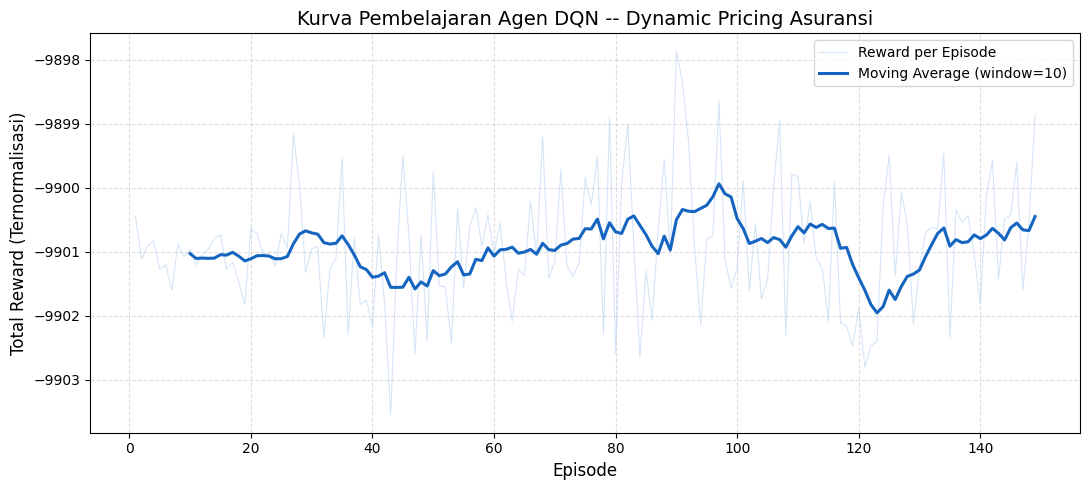

In [10]:
def plot_learning_curve(episode_rewards: list, save_path: str = None):
    """Memplot kurva total reward per episode beserta moving average."""
    if not episode_rewards:
        print("Tidak ada data reward untuk diplot.")
        return

    rewards  = np.array(episode_rewards)
    episodes = np.arange(1, len(rewards) + 1)

    window     = min(10, len(rewards))
    moving_avg = np.convolve(rewards, np.ones(window) / window, mode="valid")
    ma_episodes = np.arange(window, len(rewards) + 1)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(episodes, rewards, color="#AECBF0", alpha=0.5,
            linewidth=0.8, label="Reward per Episode")
    ax.plot(ma_episodes, moving_avg, color="#1565C0",
            linewidth=2.2, label=f"Moving Average (window={window})")
    ax.set_xlabel("Episode", fontsize=12)
    ax.set_ylabel("Total Reward (Ternormalisasi)", fontsize=12)
    ax.set_title("Kurva Pembelajaran Agen DQN -- Dynamic Pricing Asuransi", fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Kurva pembelajaran disimpan ke: {save_path}")

    plt.show()
    plt.close()


lc_path = os.path.join(ARTIFACT_DIR, "learning_curve.png")
plot_learning_curve(reward_logger.episode_rewards, save_path=lc_path)

## 9. Tabel Ringkasan Hyperparameter

In [11]:
hyperparam_df = pd.DataFrame({
    "Hyperparameter"       : [
        "Algoritma", "Policy", "Arsitektur Jaringan Q",
        "Learning Rate (alpha)", "Batch Size", "Replay Buffer Size",
        "Discount Factor (gamma)", "Epsilon Awal", "Epsilon Akhir",
        "Epsilon Decay", "Target Network Update", "Total Timesteps", "Seed",
    ],
    "Nilai"                : [
        "DQN (Deep Q-Network)", "MlpPolicy", "[6] -> [64] -> [64] -> [5]",
        str(LEARNING_RATE), str(BATCH_SIZE), f"{BUFFER_SIZE:,}",
        str(GAMMA), "1.0", str(EXPLORATION_FINAL_EPS),
        f"Linear selama {EXPLORATION_FRACTION*100:.0f}% timesteps",
        f"Setiap {TARGET_UPDATE_INTERVAL} langkah",
        f"{TOTAL_TIMESTEPS:,}", str(SEED),
    ],
})

print("Tabel Hyperparameter DQN:")
print(hyperparam_df.to_string(index=False))

Tabel Hyperparameter DQN:
         Hyperparameter                       Nilai
              Algoritma        DQN (Deep Q-Network)
                 Policy                   MlpPolicy
  Arsitektur Jaringan Q  [6] -> [64] -> [64] -> [5]
  Learning Rate (alpha)                       0.001
             Batch Size                          64
     Replay Buffer Size                      50,000
Discount Factor (gamma)                        0.95
           Epsilon Awal                         1.0
          Epsilon Akhir                        0.05
          Epsilon Decay Linear selama 30% timesteps
  Target Network Update          Setiap 500 langkah
        Total Timesteps                     200,000
                   Seed                          42


## 10. Ringkasan

Notebook ini telah menyelesaikan:

1. Preprocessing data (encoding + scaling).
2. Pembuatan dan validasi `InsurancePricingEnv`.
3. Pelatihan agen DQN selama 200.000 timesteps dengan arsitektur MLP [64, 64].
4. Perekaman reward per episode menggunakan `RewardLoggerCallback`.
5. Penyimpanan model ke `models/dqn_insurance_pricing.zip`.
6. Visualisasi kurva pembelajaran.

**Langkah Berikutnya**: Jalankan `03_evaluasi_dan_qtable.ipynb` untuk mengevaluasi model dan melihat tabel Q-value.